Student name: Likhita Magar 
batch: 2026
date: oct 3, 2026
dataset name: WA_Fn-UseC_-Telco-Customer-Churn.csv
Kaggle URL: https://www.kaggle.com/datasets/blastchar/telco-customer-churn


Problem definition
Business context, the two tasks, targets (half a page)


In [3]:
# # Dataset understanding Section 1

# # Q1.1 [Written] In 2–3 sentences, describe the business objective behind this dataset. Who would use the
# # model's predictions, and what decision would those predictions support?

# # Ans: It is going to be useful for retention team for them to contact the in-risk customers with discounts or other offers.



# # Q1.2 [Code + Written] What is the target variable for the primary task? Show its value counts and
# # proportions. What do you notice about the balance between the classes?

# # Ans: 
import pandas as pd
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df['Churn'].value_counts()
df['Churn'].value_counts(normalize=True)

# # The target variable is Churn. Churn indicates wheather the customer leaves within last month or not. The value count reveals that roughly 1 out of 4 did churn. So, its class imbalance. The model that always predicts 'No' would achieve above 70% accuracy. 



# # Q1.3 [Written] Is the primary task classification or regression? Explain why. Then answer this: if the company instead wanted to predict how many months remain until a customer leaves, which type of
# # problem would that be, and what would change in your approach?

# # Ans:
# # The primary task is about classification as it talks about category (yes/no). It the company wanted to predict how many months remain until a customer leaves then it will be regression as it will be about numbers. I'd change:
# # the target variable, the metrics (MAE, RMSE instead of accuracy) and the model to regressors instead of classifier.


# # Q1.4 [Code + Written] List the input features. Is there any column that should never be used as a model input, whatever the task? Justify your answer.

# # Ans:
print(list(df.columns))
# # Its a list of all columns as input feature except Churn. customerID should never be used as its unique identifier with no predictive meaning. It would let the model memorize specific customers.


# # Q1.5 [Code + Written] Build a table with these columns: Column · pandas dtype · Your classification
# # (numerical / binary / nominal categorical / ordinal categorical) · Reason. The dtype pandas reports and the
# # real meaning of a column do not always agree. Find at least two columns where they disagree, and
# # explain what would go wrong if you trusted the pandas dtype.

# # Ans:

# # Column	            pandas dtype	    Your classification	        Reason
# # customerID	        object	            Identifier	                Unique, no predictive value
# # gender	            object	            Binary categorical	        Male/Female
# # SeniorCitizen	    int64	            Binary categorical	        0/1 but means No/Yes
# # tenure	            int64	            Numerical	                Months, continuous
# # TotalCharges	    object	            Numerical (after fix)	Stored as string due to blanks

# # the two dtype disaggreements:
# # 1. SeniorCitizen: int64 but binary categorical
# # 2. TotalCharges: object but numerical


# # Q1.6 [Code + Written] Identify missing values. - Checking isnull() alone may not show every missing
# # value in this dataset. Look at how each column is stored. - For each column with missing values, reporthow many there are and investigate why they are missing. Look at the other columns for those rows. -
# # The Feature Engineering lecture distinguished values that were not recorded from values that are not
# # applicable. Which kind is this? What handling does that suggest?

# # Ans:
df.isnull().sum()

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].isnull().sum()

# # These are customers with tenure=0 - they haven't been billed yet.



# # Q1.7 [Code + Written] Check the numerical columns for outliers using the IQR rule (1.5 × IQR) and a
# # visual check (boxplot or histogram). Report how many values each method flags. Are they errors or
# # legitimate extreme customers? Would you remove them? Justify your answer.

# # Ans:
Q1 = df['tenure'].quantile(0.25)
Q3 = df['tenure'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR
outliers = df[(df['tenure'] < lower) | (df['tenure'] > upper)]

# decison is to keep them. They're legitimate customers like long tenure, high bills.
# its not errors.



# Q1.8 [Written] Leakage check. For each task, list any feature that could cause data leakage. Consider when each value becomes known compared with the moment the prediction is made. - (a) Predicting Churn for current customers. - (b) Predicting MonthlyCharges for a prospective customer who has not signed up yet (this is the setting used in Section 8).

# Ans:
# a. Churn Prediction:
#  - Churn itself (target)
#  - TotalCharges - if it includes the final month's charges after cancellation
#  - Any features that's only known after the customer decides to leaves

# b. MonthlyCharges regression (R - B):
#  - TotalCharges - its derived from MonthlyCharges x tenure
#  - Churn - not known for prospective customers
#  - tenure - not known for prospective customers (they haven't signed up)


# Q1.9 [Written] Make a prediction before modelling. Rank the 5 features you expect to matter most for predicting churn, with one sentence of reasoning for each. Do not change this answer later. You will compare it with the model's feature importances in Section 6.

# Ans:
# 1. Contract - month-to-month customers churn more
# 2. tenure - new customers churn more
# 3. MonthlyCharges - higher bills -> more churn
# 4. InternetService - fiber optic customers churn more
# 5. TotalCharges - proxy for tenure/value

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


Shape:  (7043, 21)

Data types after fixes: customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Proportions:
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


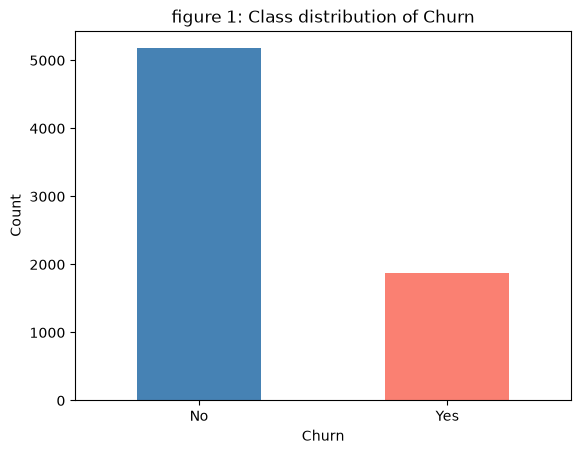

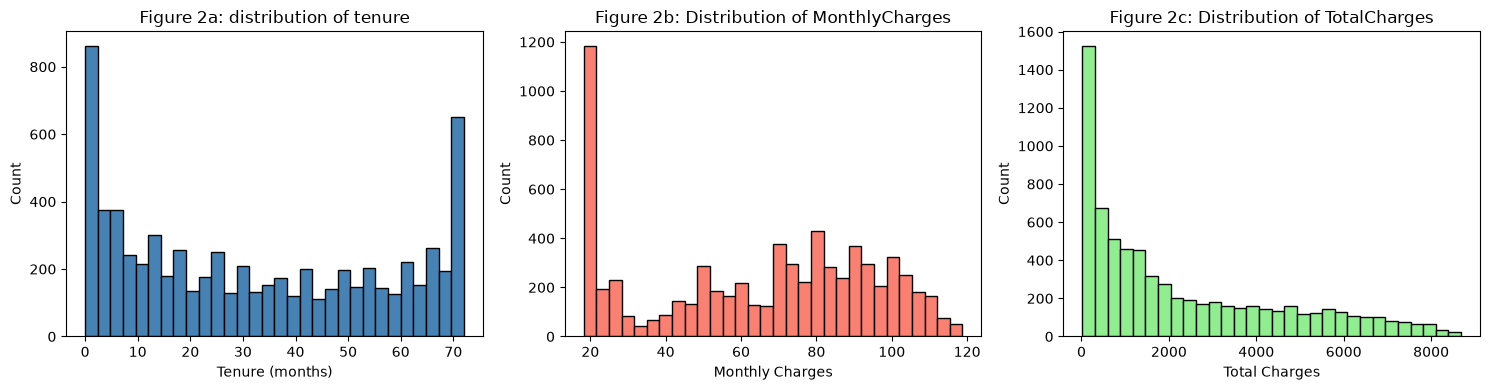

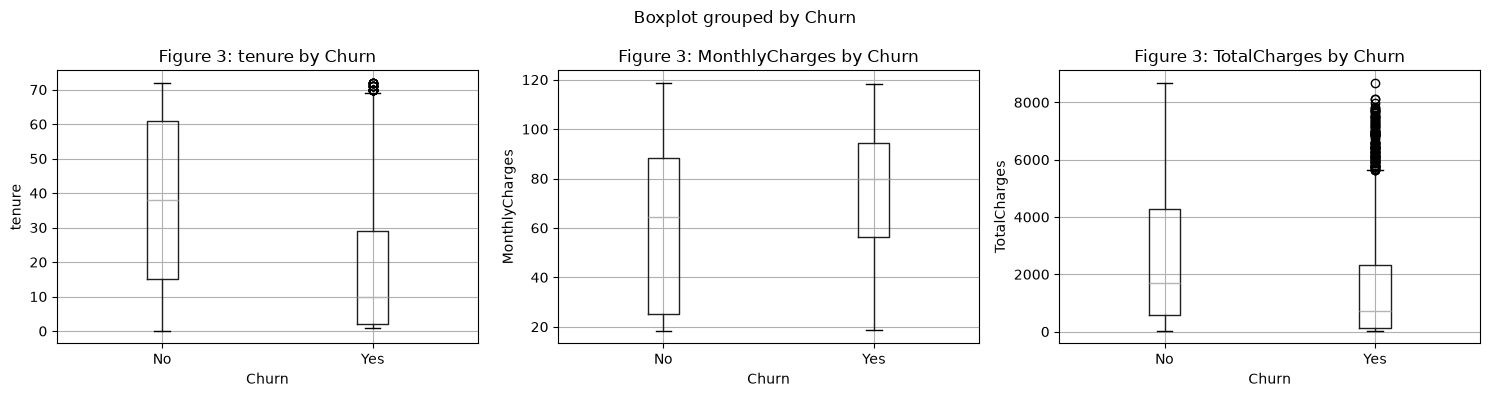

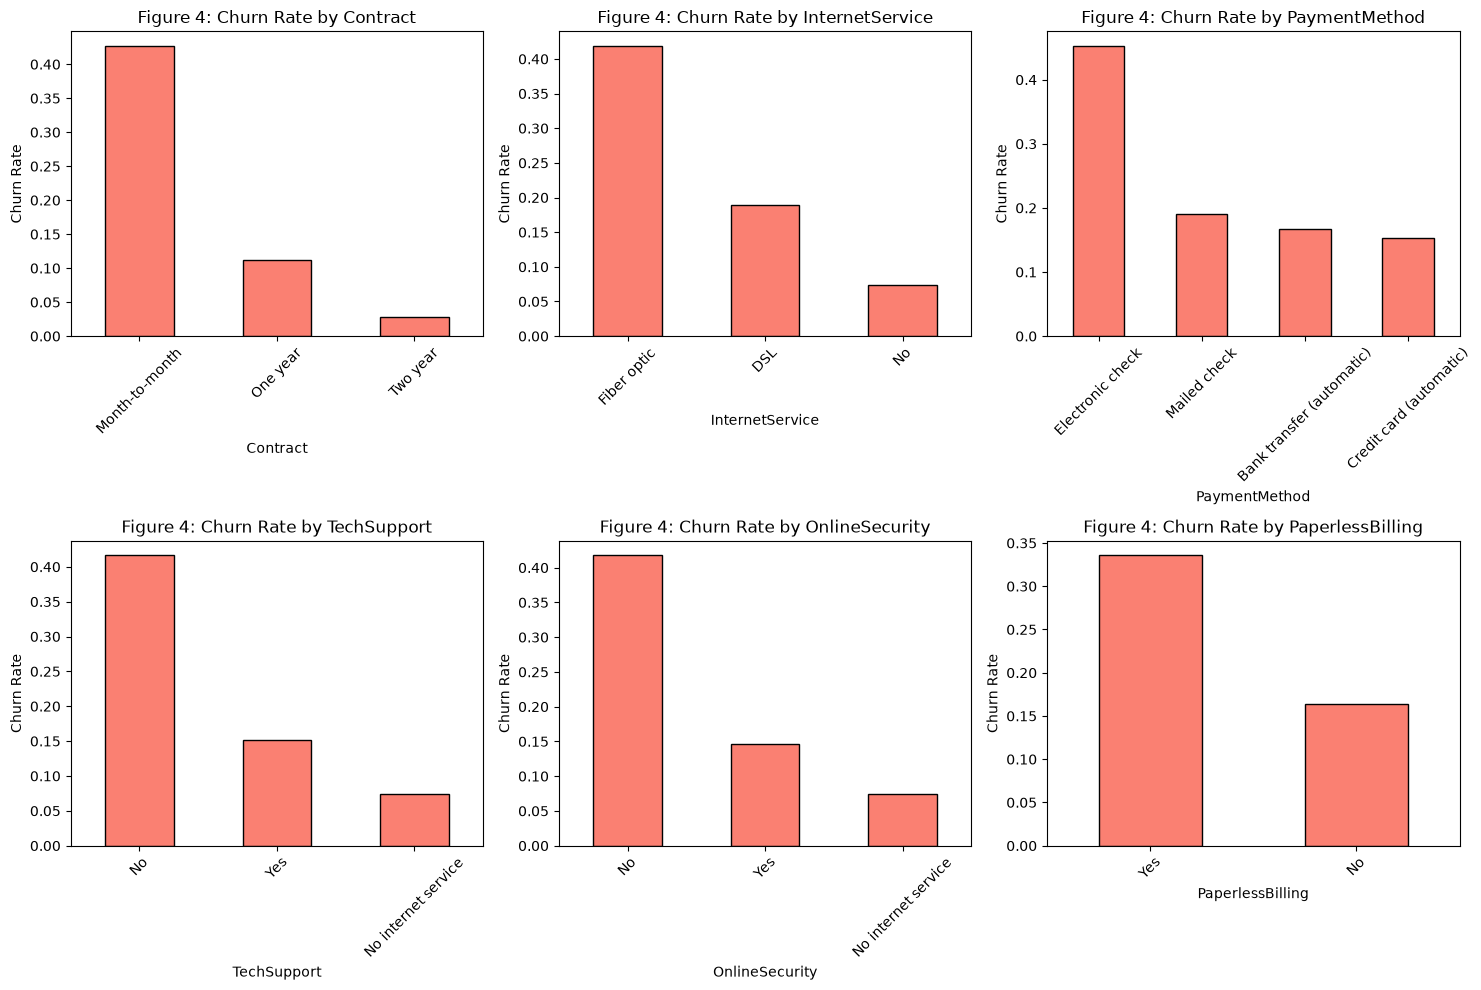

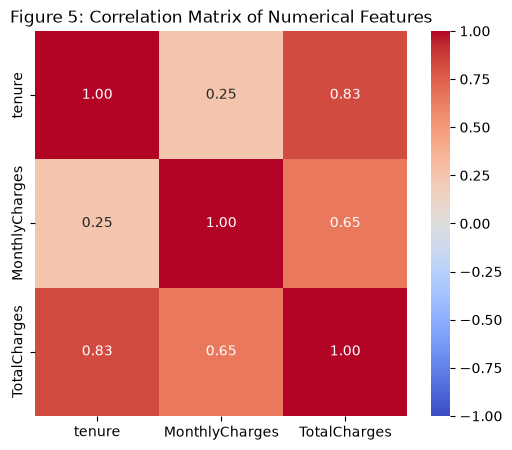

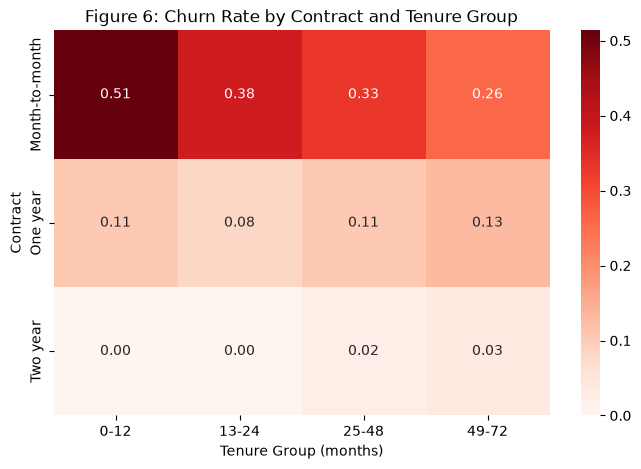

In [6]:
# EDA Section 2

# E2.1 [Code] Report the shape of the dataset and a summary of data types after your Section 1 fixes.

# Ans:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("Shape: ", df.shape)
print("\nData types after fixes:", df.dtypes)

# We dropped customerID and fixed TotalCharges type. Now, dataset has 7,043 rows and 20 columns. There are 3 numerical columns (tenure, MonthlyCharges, TotalCharges) and 17 categorical columns.



# E2.2 [Code + Written] Show the class distribution of Churn . What does the imbalance mean for (a) how you split the data, and (b) how you will read accuracy scores later?

# Ans:
print(df['Churn'].value_counts())
print("\nProportions:")
print(df['Churn'].value_counts(normalize=True))

# # Plot
import matplotlib.pyplot as plt

df['Churn'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('figure 1: Class distribution of Churn')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

# The dataset is imbalanced as 73% of customiers did not chrun and 27% did churn. For splitting, I must use stratified sampling as both training and test sets preserve the same 73/27 ratio. For reading accuracy, alone accuracy is misleading - a majority class baseline achieves 73% accuracy while identifying zero churners. I will therefore rely on recall (to catch churners), F1 (balance of precision and recall) and AUC-ROC (overall ranking ability) as my main metrics.




# E2.3 [Code + Written] Plot the distributions of tenure , MonthlyCharges and TotalCharges . Describe each shape (symmetric, skewed, bimodal, …). Is any transformation worth considering? Does the answer depend on which model you plan to use?

# Ans:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df['tenure'], bins=30, color='steelblue', edgecolor='black')
axes[0].set_title('Figure 2a: distribution of tenure')
axes[0].set_xlabel('Tenure (months)')
axes[0].set_ylabel('Count')

axes[1].hist(df['MonthlyCharges'], bins=30, color='salmon', edgecolor='black')
axes[1].set_title('Figure 2b: Distribution of MonthlyCharges')
axes[1].set_xlabel('Monthly Charges')
axes[1].set_ylabel('Count')

axes[2].hist(df['TotalCharges'].dropna(), bins=30, color='lightgreen', edgecolor='black')
axes[2].set_title('Figure 2c: Distribution of TotalCharges')
axes[2].set_xlabel('Total Charges')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

# Tenure is bimodal - many customers are either very new (0-5 months) or very loyal (65-72 months). MonthlyCharges is roughly uniform with slight peaks at low and high values. TotalCharges is right-skewed, with most customers having low total charges and a long tail of high spenders. A log transformation could help linear models (Logistic Regression,, SVM) by reducing skewness, but tree-based models (Decision Tree, Random Forest), do not need it because they split on thresholds rather than assuming a distribution.



# E2.4 [Code + Written] Compare the numerical features between churners and non-churners, for example with boxplots or overlaid histograms split by Churn . Which numerical feature separates the two groups most clearly?

# Ans:

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(['tenure', 'MonthlyCharges', 'TotalCharges']):
    df.boxplot(column=col, by='Churn', ax=axes[i])
    axes[i].set_title(f'Figure 3: {col} by Churn')
    axes[i].set_xlabel('Churn')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

# Tenure separates churners from non-churners most clearly: churners have a median tenure of about 10 months, while non-churners have a median of about 38 months. MonthlyCharges and TotalCharges also show differences but with more overlap. This suggests tenure will be a strong predictor in the model.



# E2.5 [Code + Written] For at least six categorical features, plot the churn rate per category (the percentage of customers in that category who churned), not raw counts. - Why is the churn rate moreuseful than the raw count for this purpose? - Which categories have the highest and lowest churn rates?

# Ans:

cat_features = ['Contract', 'InternetService', 'PaymentMethod',
                'TechSupport', 'OnlineSecurity', 'PaperlessBilling']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    churn_rate = df.groupby(col)['Churn'].apply(
        lambda x: (x == 'Yes').mean()
    ).sort_values(ascending=False)
    
    churn_rate.plot(kind='bar', ax=axes[i], color='salmon', edgecolor='black')
    axes[i].set_title(f'Figure 4: Churn Rate by {col}')
    axes[i].set_ylabel('Churn Rate')
    axes[i].set_xlabel(col)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Six categorical features show strong differences in churn rate. Contract is the strongest: month-to-month customers churn at ~42%, compared to ~11% for one-year and ~3% for two-year contracts. Fiber optic internet customers churn at ~42% vs ~19% for DSL. Electronic check payment churns at ~45%. Customers without TechSupport or OnlineSecurity churn at ~41-42%. Paperless billing customers churn at ~34% vs ~16%. These features will be important predictors.



# E2.6 [Code + Written] Compute and display a correlation matrix for the numerical features. Which pairs are strongly correlated? Using the idea of redundant features from the Feature Engineering lecture, explain whether this matters, and for which kinds of model.

# Ans:

import seaborn as sns

num_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
corr = df[num_features].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Figure 5: Correlation Matrix of Numerical Features')
plt.show()

# Tenure and TotalCharges are strongly correlated (r = 0.83), which makes sense because total charges accumulate over time. This is redundancy: both features carry similar information. For linear models, this causes multicollinearity and unstable coefficients — I might drop one or use Ridge regularization. For tree-based models, it's less of a problem because trees select the best split at each node and can ignore redundant features.



# E2.7 [Code + Written] Explore one interaction between two features, for example churn rate by
# Contract across tenure groups. Does the effect of one feature change depending on the value of the other? What does this suggest about linear models compared with tree-based models?

# Ans:

df['tenure_group'] = pd.cut(df['tenure'],
                            bins=[0, 12, 24, 48, 72],
                            labels=['0-12', '13-24', '25-48', '49-72'])

# Churn rate by Contract and tenure_group
pivot = df.pivot_table(values='Churn',
                       index='Contract',
                       columns='tenure_group',
                       aggfunc=lambda x: (x == 'Yes').mean())

plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, cmap='Reds', fmt='.2f')
plt.title('Figure 6: Churn Rate by Contract and Tenure Group')
plt.xlabel('Tenure Group (months)')
plt.ylabel('Contract')
plt.show()

# Churn rate by Contract and tenure group shows an interaction: month-to-month customers churn heavily at all tenure levels, but especially when new (0-12 months: ~55%). Two-year customers rarely churn regardless of tenure. This suggests that linear models, which assume features act independently, may underperform. Tree-based models can capture this interaction naturally because they split on Contract first, then on tenure within each branch.



# Q2.8 [Written] Summarise the three most useful findings from your EDA. For each one, say which
# specific modelling decision it will influence.

# Ans:
# Finding 1: Class imbalance (73% No, 27% Yes).
# Implication: I will use statified splitting and I will choose recall/F1/AUC-ROC as my main metrics instead of accuracy.

# Finding 2: Contract is the strongest categorical predictor.
# Implication: I will ensure Contract is properly encoded (ordinal or one-hot) and expect it to be a top feature in the model.

# Finding 3: Tenure and TotalCharges are strongly correlated (r=83).
# Implication: For linear models, I will consider dropping one or using Ridge regulatization to handle multicollinearity. For tree models, I will keep both.

In [ ]:
# Feature engineering Section 3

# Q3.1 [Written] Create a transformation plan table: Column(s) · Problem found · Action taken · Which models need this action. Cover type conversions, missing values, encoding, scaling and any removals.

# Ans:
import pandas as pd

prep_table = pd.DataFrame(
    [
        ["customerID", "Unique identifier, no predictive value", "Drop", "All"],
        ["TotalCharges", "Stored as object due to blank spaces; 11 missing values", "Convert to numeric; impute missing with median", "All"],
        ["SeniorCitizen", "Stored as int64 but is binary categorical", "Treat as categorical (already 0/1, no encoding needed)", "All"],
        ["Contract", "Text categories with order", "Ordinal encode (0, 1, 2)", "All"],
        ["PaymentMethod", "Text categories, no order", "One-hot encode", "All"],
        ["Service columns (OnlineSecurity, etc.)", 'Three values including "No internet service"', "One-hot encode with handle_unknown='ignore'", "All"],
        ["tenure, MonthlyCharges, TotalCharges", "Different scales", "StandardScaler", "Logistic Regression, SVM"],
        ["Tree-based models (all numerical)", "Different scales", "No scaling needed", "Decision Tree, Random Forest"],
    ],
    columns=["Column(s)", "Problem found", "Action taken", "Which models need this"],
)

prep_table.style.hide(axis="index").set_properties(**{"text-align": "left"})



# Q3.2 [Code + Written] Handle the missing values you found in Q1.6. Justify your method using your investigation from Q1.6. Would a mean or median fill make sense here? Why or why not? Show the missing-value counts after handling

# Ans:
print('Missing before:', df['TotalCharges'].isnull().sum())

median_val = df['TotalCharges'].median()
df['TotalCharges'] = df['TotalCharges'].fillna(median_val)
print('Missing after:', df['TotalCharges'].isnull().sum())

# TotalCharges is right skewed with outliers. The mean would be pulled up by high-value customers. The median is robust - its just the middle value.
# But, logically for the 11 customers as their tenure = 0 means they haven't been billed. So, TotalCharges should be 0 not the median. 



# Q3.3 [Code + Written] Encode the categorical variables. - (a) For each categorical column, choose one-hot or ordinal encoding and justify the choice. - (b) Is Contract nominal or ordinal? Argue both sides, then choose. - (c) Several service columns contain a third value as well as Yes/No. What does that value mean, which other column does it depend on, and how will you encode it? What redundancy does this create? - (d) What should your encoder do if it meets a category at prediction time that it never saw during training? How did you configure it for this?

# Ans:
print(list(df.columns))
print(df.dtypes)

# (a) Encoding choice per column
encoding_table = pd.DataFrame(
    [
        ['gender', 'Male, Female', 'No', 'One-hot', 'No category is "more" than another'],
        ['SeniorCitizen', '0, 1', 'No', 'Already 0/1 — treat as numeric binary', "It's already numeric, but it means Yes/No. Trees can use it directly. Linear models treat it as a number — which is fine for binary."],
        ['Partner', 'Yes, No', 'No', 'One-hot', 'Binary, no order'],
        ['Dependents', 'Yes, No', 'No', 'One-hot', 'Binary, no order'],
        ['PhoneService', 'Yes, No', 'No', 'One-hot', 'Binary, no order'],
        ['MultipleLines', 'Yes, No, No phone service', 'No', 'One-hot', 'Three categories, no order'],
        ['InternetService', 'DSL, Fiber optic, No', 'No', 'One-hot', 'Three categories, no order (Fiber isn\'t "more" than DSL)'],
        ['OnlineSecurity', 'Yes, No, No internet service', 'No', 'One-hot', 'No order'],
        ['OnlineBackup', 'Yes, No, No internet service', 'No', 'One-hot', 'No order'],
        ['DeviceProtection', 'Yes, No, No internet service', 'No', 'One-hot', 'No order'],
        ['TechSupport', 'Yes, No, No internet service', 'No', 'One-hot', 'No order'],
        ['StreamingTV', 'Yes, No, No internet service', 'No', 'One-hot', 'No order'],
        ['StreamingMovies', 'Yes, No, No internet service', 'No', 'One-hot', 'No order'],
        ['Contract', 'Month-to-month, One year, Two year', 'Debatable', 'See (b)', 'Has order but distances unequal'],
        ['PaperlessBilling', 'Yes, No', 'No', 'One-hot', 'Binary, no order'],
        ['PaymentMethod', 'Electronic check, Mailed check, Bank transfer, Credit card', 'No', 'One-hot', 'Four categories, no order'],
        ['tenure_group', '0-12, 13-24, 25-48, 49-72', 'Yes', 'Ordinal', 'Has clear order (new → loyal)'],
    ],
    columns=['Column', 'Values', 'Order?', 'Encoding', 'Justification'],
)

encoding_table.style.hide(axis='index').set_properties(**{'text-align': 'left'})

# b. 
# contract is ordinal
# argument:
# 1. it has a clea order: month-to-month < one year < 2 year
# 2. longer contracts = more commitment
# 3. The model can learn 'higher number = longer commitment = less churn'
# 4. ordinal encoding (0, 1, 2) preserves this order in a single column
# 5. one-hot would create 3 columns and lose the order information

# contract is nominal
# argument:
# 1. the 'distance' between month-to-month and one year is not the same as between one year and two year
# 2. month-to-month - one year is a big gap
# 3. ordinal encoding assumes equal distances (0->1 is the same as 1->2)
# 4. one-hot avoids this assumption

# I would choose to treat it as ordinal. As, the monotonic churn pattern (42% - 100 % - 3%) shows the order is meaningful. If we used one-hot, we'd lose this information and the model would have to learn the order from scratch. 

# c. Seven columns contain a third value: "No phone service" (MultipleLines) or "No internet service" (OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies). This means the customer doesn't have phone/internet, so the add-on is impossible. It depends on PhoneService and InternetService respectively. This creates redundancy: "No internet service" is the same information as InternetService = "No". I combined "No" and "No internet service" into a single "No" category. This avoids redundancy and simplifies the feature space. The model can still distinguish these customers by using InternetService/PhoneService as separate features.

# d. I configured my OneHotEncoder with handle_unknown='ignore' and sparse_output=False. If a category appears at prediction time that wasn't in the training data, the encoder produces all zeros for that feature instead of crashing.
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)



# Q3.4 [Code + Written] Apply scaling where needed. - Which scaler did you choose (standardisation or min-max), and why? Consider what you found about outliers in Q1.7. - Show summary statistics (mean, std, min, max) for two scaled columns, before and after scaling, computed on the training set. - Which of your planned models need scaling, and which do not? Explain why tree-based models do not need it.

# Ans:



Missing before: 0
Missing after: 0
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'tenure_group']
customerID               str
gender                   str
SeniorCitizen          int64
Partner                  str
Dependents               str
tenure                 int64
PhoneService             str
MultipleLines            str
InternetService          str
OnlineSecurity           str
OnlineBackup             str
DeviceProtection         str
TechSupport              str
StreamingTV              str
StreamingMovies          str
Contract                 str
PaperlessBilling         str
PaymentMethod            str
MonthlyCharges       float64
TotalCharges         float64
Churn                    str
tenure_group    

Column,Values,Order?,Encoding,Justification
gender,"Male, Female",No,One-hot,"No category is ""more"" than another"
SeniorCitizen,"0, 1",No,Already 0/1 — treat as numeric binary,"It's already numeric, but it means Yes/No. Trees can use it directly. Linear models treat it as a number — which is fine for binary."
Partner,"Yes, No",No,One-hot,"Binary, no order"
Dependents,"Yes, No",No,One-hot,"Binary, no order"
PhoneService,"Yes, No",No,One-hot,"Binary, no order"
MultipleLines,"Yes, No, No phone service",No,One-hot,"Three categories, no order"
InternetService,"DSL, Fiber optic, No",No,One-hot,"Three categories, no order (Fiber isn't ""more"" than DSL)"
OnlineSecurity,"Yes, No, No internet service",No,One-hot,No order
OnlineBackup,"Yes, No, No internet service",No,One-hot,No order
DeviceProtection,"Yes, No, No internet service",No,One-hot,No order


In [ ]:
# Model experiments Sections 4–8


In [ ]:
# Evaluation results and model comparison Section 9


In [ ]:
# Conceptual answers Section 10


In [ ]:
# Scenario answers Section 11


In [ ]:
# Final analysis